In [ ]:
from enum import Enum
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import predykcja_nn as pred_nn
import pickle

class delay_type(Enum):
    EARLY=0
    NO_DELAY=1
    SMALL_DELAY=2
    MEDIUM_DELAY=3
    BIG_DELAY=4
    GREAT_DELAY=5
    HUGE_DELAY=6

delays_labeled=pd.read_csv('delays_final_labeled.csv')
delays_labeled=delays_labeled.drop(columns='Unnamed: 0')
delays_labeled['day']=delays_labeled['day'].astype(int)




In [2]:


# group1 = [192, 501, 503, 159, 179, 513, 169, 469]
# group2 = [174, 578, 178, 155]
# group3 = [248, 238, 268, 108, 278, 288, 258, 230]

# delays_labeled=delays_labeled.loc[delays_labeled['delay_min']<1700]


# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group1+group2+group3)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes.csv')

In [3]:
# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group1)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes_group_1.csv')

In [4]:
# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group2)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes_group_2.csv')

In [5]:
# selected_routes = delays_labeled.loc[delays_labeled['route_name'].isin(group3)]

# selected_routes['godzina'] = (selected_routes['time_label'] // 100) * 60 + (selected_routes['time_label'] % 100)
# selected_routes['sin_time'] = np.sin(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes['cos_time'] = np.cos(2 * np.pi * selected_routes['godzina'] / 1440)
# selected_routes=selected_routes.drop(columns='godzina')

# selected_routes.to_csv('labeled_selected_routes_group_3.csv')


In [6]:


wyniki=pred_nn.predykcja_nn('labeled_selected_routes_group_3.csv',epochs=30)


Epoch 1/30 | Train Loss: 61.7349 | Test Loss: 51.9643
Epoch 2/30 | Train Loss: 54.1926 | Test Loss: 49.0716
Epoch 3/30 | Train Loss: 52.3482 | Test Loss: 46.6965
Epoch 4/30 | Train Loss: 51.1852 | Test Loss: 45.8273
Epoch 5/30 | Train Loss: 50.4980 | Test Loss: 44.7684
Epoch 6/30 | Train Loss: 49.6901 | Test Loss: 44.1241
Epoch 7/30 | Train Loss: 49.1066 | Test Loss: 43.4054
Epoch 8/30 | Train Loss: 48.3043 | Test Loss: 42.7898
Epoch 9/30 | Train Loss: 47.8901 | Test Loss: 42.2428
Epoch 10/30 | Train Loss: 47.8936 | Test Loss: 41.8340
Epoch 11/30 | Train Loss: 46.7264 | Test Loss: 41.3888
Epoch 12/30 | Train Loss: 46.1641 | Test Loss: 40.5357
Epoch 13/30 | Train Loss: 45.5949 | Test Loss: 39.8498
Epoch 14/30 | Train Loss: 45.2041 | Test Loss: 39.1789
Epoch 15/30 | Train Loss: 44.4461 | Test Loss: 38.6657
Epoch 16/30 | Train Loss: 44.0076 | Test Loss: 38.4814
Epoch 17/30 | Train Loss: 43.6714 | Test Loss: 38.5491
Epoch 18/30 | Train Loss: 43.3230 | Test Loss: 37.8313
Epoch 19/30 | Train

In [7]:

wyniki_zapis=[wyniki['train_losses'],wyniki['test_losses'],wyniki['results']]

plik=open('../data/wyniki_predykcji/grupa_3_bez_cv_30_epoch','ab')
pickle.dump(wyniki_zapis,plik)
plik.close()



In [8]:
df_results = wyniki['results']

df_results

,route_name,y_true,y_pred
0,6,6.266667,3.656150
1,4,0.566667,1.769156
2,6,4.566667,4.433429
3,6,0.666667,1.145106
4,4,16.799999,5.771801
...,...,...,...
6752,4,1.933333,1.341027
6753,6,-0.266667,-0.831857
6754,0,2.016667,0.925517
6755,2,1.250000,-0.356785


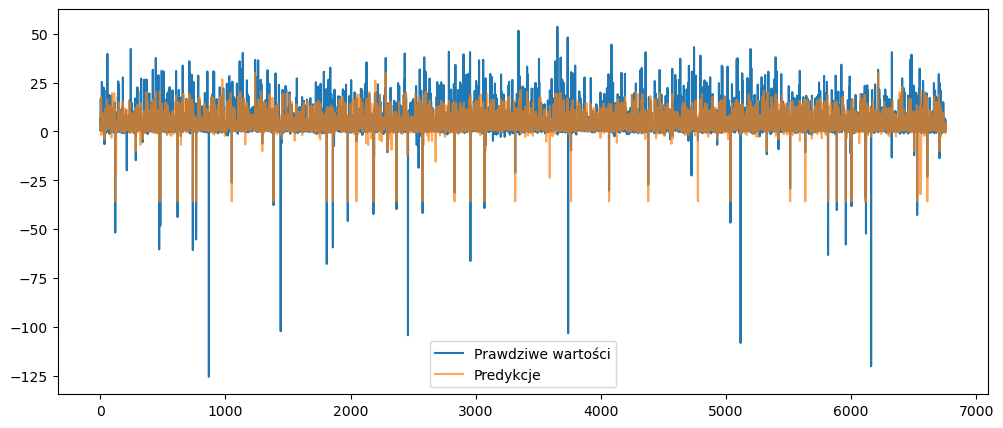

In [9]:

plt.figure(figsize=(12,5))
plt.plot(df_results["y_true"], label="Prawdziwe wartości")
plt.plot(df_results["y_pred"], label="Predykcje", alpha=0.7)
plt.legend()
plt.show()

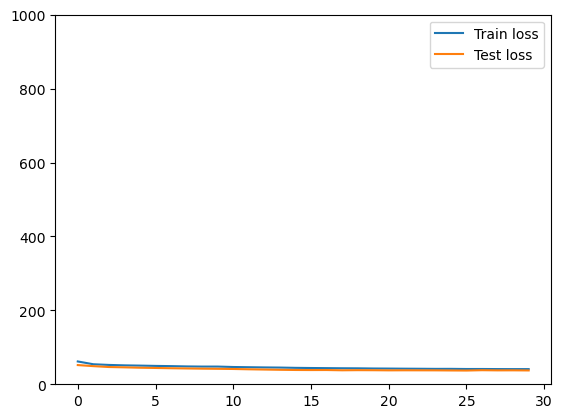

In [10]:


plt.figure
plt.plot(wyniki['train_losses'],label='Train loss')
plt.plot(wyniki['test_losses'],label='Test loss')
plt.ylim([0,1000])
plt.legend()
plt.show()

In [11]:
wyniki=pred_nn.predykcja_nn_cv('labeled_selected_routes_group_3.csv',epochs=30)

plik=open('../data/wyniki_predykcji/grupa_3_5cv_30_epoch','ab')
pickle.dump(wyniki,plik)
plik.close()



===== Fold 1/5 =====
Avg train loss in epoch 0:62.6766
Avg train loss in epoch 1:55.5817
Avg train loss in epoch 2:53.8797
Avg train loss in epoch 3:52.4075
Avg train loss in epoch 4:51.3740
Avg train loss in epoch 5:50.4520
Avg train loss in epoch 6:49.6044
Avg train loss in epoch 7:48.7715
Avg train loss in epoch 8:48.3449
Avg train loss in epoch 9:47.5412
Avg train loss in epoch 10:46.8262
Avg train loss in epoch 11:46.0577
Avg train loss in epoch 12:45.8360
Avg train loss in epoch 13:45.0820
Avg train loss in epoch 14:44.6072
Avg train loss in epoch 15:44.2811
Avg train loss in epoch 16:43.7722
Avg train loss in epoch 17:43.3836
Avg train loss in epoch 18:43.1037
Avg train loss in epoch 19:42.7774
Avg train loss in epoch 20:42.7533
Avg train loss in epoch 21:42.4796
Avg train loss in epoch 22:42.2158
Avg train loss in epoch 23:41.9369
Avg train loss in epoch 24:41.7506
Avg train loss in epoch 25:41.6622
Avg train loss in epoch 26:41.6776
Avg train loss in epoch 27:41.3494
Avg trai

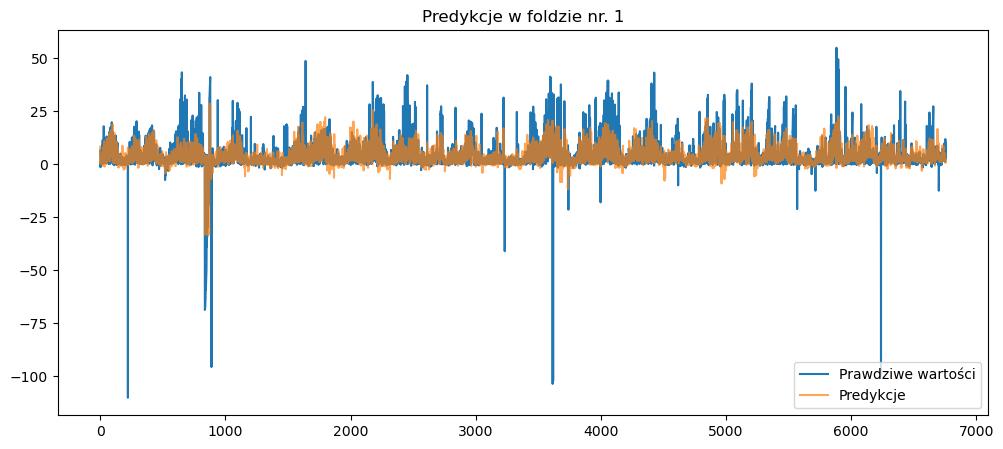

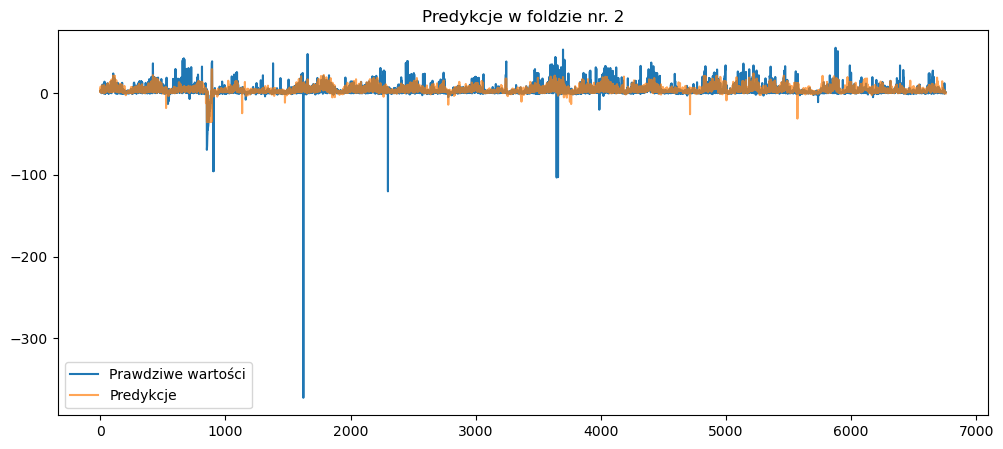

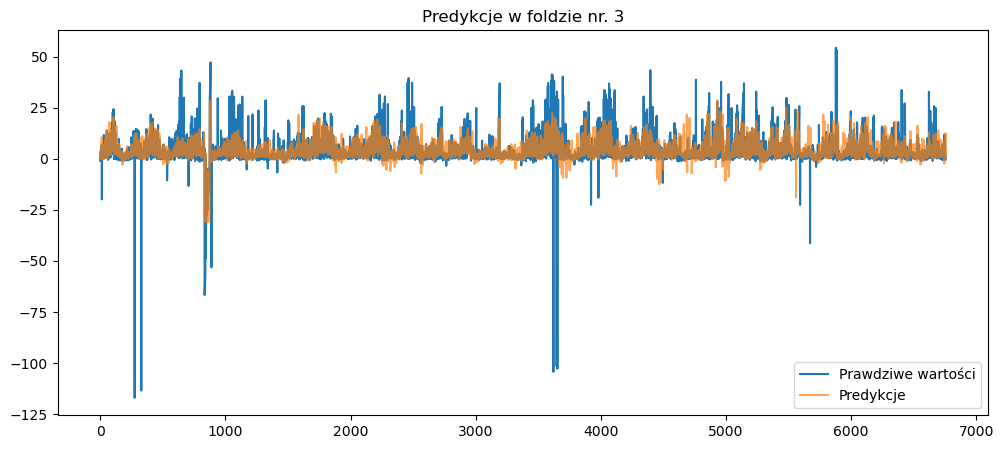

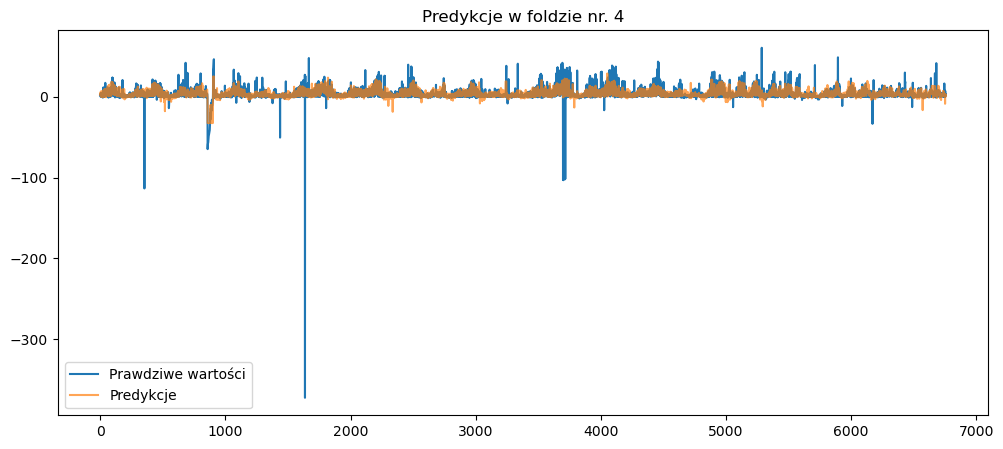

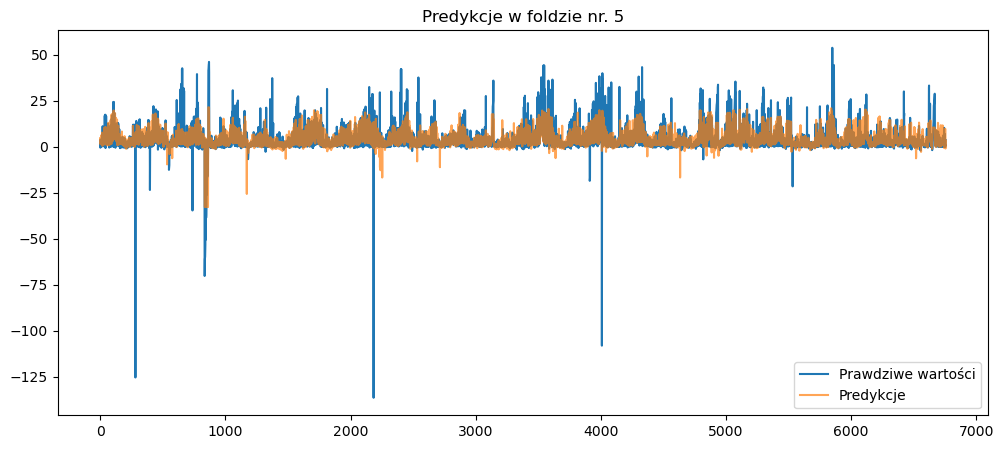

In [12]:


for i in range(5):
    predykcje=wyniki['fold_preds'][i]
    plt.figure(figsize=(12,5))
    plt.plot(predykcje["y_true"], label="Prawdziwe wartości")
    plt.plot(predykcje["y_pred"], label="Predykcje", alpha=0.7)
    plt.legend()
    plt.title(f'Predykcje w foldzie nr. {i+1}')
    plt.show()